# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Advanced filter methods:** Build on the filters from this notebook to  emulate filters from social media or photo-editing apps!
* **Advanced image recognition techniques:** Extend the object detection problem to be more general, handle more objects, etx

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1:
* Source 2:
* Source 3:
* Source 4:
* Source 5:

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [1]:
!git clone https://github.com/gaoruosong/CS131_release.git

Cloning into 'CS131_release'...
remote: Enumerating objects: 2744, done.
remote: Counting objects: 100% (419/419), done.
remote: Compressing objects: 100% (335/335), done.
remote: Total 2744 (delta 299), reused 84 (delta 84), pack-reused 2325 (from 3)
Receiving objects: 100% (2744/2744), 186.52 MiB | 34.36 MiB/s, done.
Resolving deltas: 100% (814/814), done.


In [2]:
%pwd

'/content'

In [3]:
%cd CS131_release/spring_2026/project1_release/option_A

/content/CS131_release/spring_2026/project1_release/option_A


In [4]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from time import time
from skimage import io
import math




%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

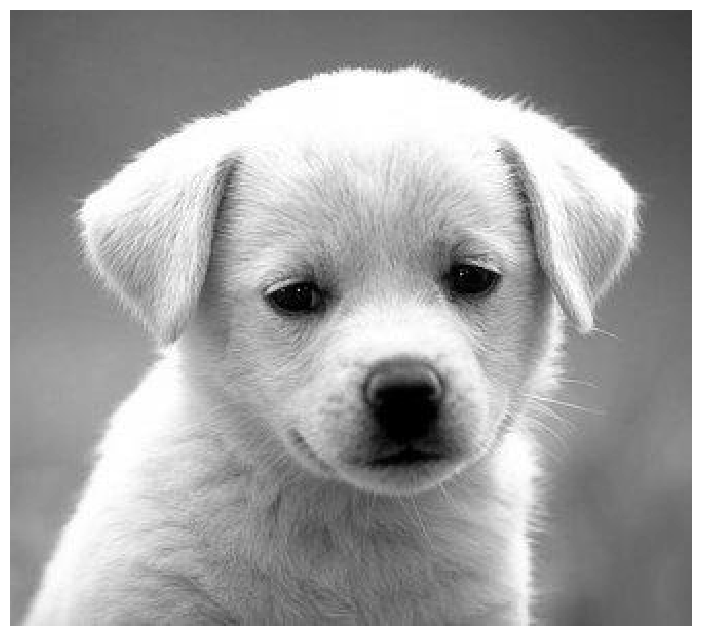

In [5]:
# Open image as grayscale
dog_img = io.imread('dog.jpg', as_gray=True)

# Show image
plt.imshow(dog_img)
plt.axis('off')
plt.show()

In [34]:
# Part (1): helper functions & default filters

# Various type issues: images can come either as integers or as floats. If it is an integer, then
# we have to clip to [0,255]. On the other hand, if a float, then it has to be clipped to [0,1].
# In other words, we should be using float in either case for computation, then clipping appropriately.
# The point being: the issue happens with clipping. Without manual clipping & conversion,
# Overflows can happen or python treats RGB int values like floats in the [0,1] range.

# After testing extensively with a ton of type conversions, this seems to be the only method.

def zero_pad(image, pad_height, pad_width, colored = False):
    """ Zero-pad an image.

    Ex: a 1x1 image [[1]] with pad_height = 1, pad_width = 2 becomes:

        [[0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0]]         of shape (3, 5)

    Args:
        image: numpy array of shape (H, W).
        pad_width: width of the zero padding (left and right padding).
        pad_height: height of the zero padding (bottom and top padding).

    Returns:
        out: numpy array of shape (H+2*pad_height, W+2*pad_width).
    """
    out = None

    if colored:
      H, W, C = image.shape  # colored
      out = np.zeros((H + 2*pad_height, W + 2*pad_width, C))
      for i in range(H):
        for j in range(W):
            out[i + pad_height, j + pad_width, :] = image[i, j, :]


    else:
      H, W = image.shape
      out = np.zeros((H + 2*pad_height, W + 2*pad_width))
      for i in range(H):
        for j in range(W):
            out[i + pad_height][j + pad_width] = image[i][j]


    if np.issubdtype(image.dtype, np.integer):
      out = np.clip(out, 0, 255)
    return out.astype(image.dtype)



def conv_fast(image, kernel, colored = False):
    """ An efficient implementation of convolution filter.

    This function uses element-wise multiplication and np.sum()
    to efficiently compute weighted sum of neighborhood at each
    pixel.

    Hints:
        - Use the zero_pad function you implemented above
        - There should be two nested for-loops
        - You may find np.flip() and np.sum() useful

    Args:
        image: numpy array of shape (Hi, Wi).
        kernel: numpy array of shape (Hk, Wk). Dimensions will be odd.

    Returns:
        out: numpy array of shape (Hi, Wi).
    """
    if colored:
      Hi, Wi, _ = image.shape
      out = np.zeros((Hi, Wi, 3))
    else:
      Hi, Wi = image.shape
      out = np.zeros((Hi, Wi))

    Hk, Wk = kernel.shape
    mid_height = Hk//2
    mid_width = Wk//2

    padded_image = zero_pad(image, mid_height, mid_width, colored)
    flipped_kernel = np.flip(kernel)

    if colored:
      for i in range(mid_height, Hi+mid_height):
        for j in range(mid_width, Wi+mid_width):
          for k in range(3):
            patch = padded_image[i-Hk+mid_height+1:i+mid_height+1, j-Wk+mid_width+1:j+mid_width+1, k].squeeze() ## important! slicing must be done in one step.
            out[i-mid_height, j-mid_width, k] = np.sum(patch * flipped_kernel)
    else:
      for i in range(mid_height, Hi+mid_height):
        for j in range(mid_width, Wi+mid_width):
            patch = padded_image[i-Hk+mid_height+1:i+mid_height+1, j-Wk+mid_width+1:j+mid_width+1] ## important! slicing must be done in one step.
            out[i-mid_height][j-mid_width] = np.sum(patch * flipped_kernel)

    print(image.dtype, image.min(), image.max())
    print(out.dtype, out.min(), out.max())
    if np.issubdtype(image.dtype, np.integer):
      out = np.clip(out, 0, 255)
    return out.astype(image.dtype)


## for small sizes, binomial filters should work just as fine as Gaussian kernel
def binomial_filter(size = 3):
  ## builds a binomial filter of dimensions size x size
  out = np.zeros((size,size))
  for i in range(size):
    for j in range(size):  ## double for loop not the most efficient, but for all practical inputs, this is completely fine
      out[i][j] = math.comb(size-1, i) * math.comb(size-1, j)
  return out/(2**(2*size-2)) ## normalize.
  ## 1, 2, 1;
  ## wait. (3,0) that is 1,3,3,1. This doesn't actually work, that's why! The matrix is wrong!
  ## Modify to math.comb(size-1, i) should fix everything.


def efficient_binomial(size = 3):
  ## builds a binomial filter of dimensions size x size, using more numpy functionalities
  column = np.zeros((size, 1))
  row = np.zeros((1, size))
  for i in range(size):
    column[i][0] = math.comb(size-1, i)
    row[0][i] = math.comb(size-1, i)
  return np.matmul(column, row)/(2**(2*size-2))


def brighten_image(image, size = 3):
  ## takes in an image and replaces each pixel with the maximal value in a centered size x size patch
  ## assumption: size << image dimensions, otherwise this function is very inefficient
  ## brighten and darken only work for B&W, because it'd be more fun later to enhance RGB scales separately.
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      patch = padded_image[i-half:i+size-half, j-half:j+size-half]     ## also slightly inefficient, can probably skip padding
      out[i-half][j-half] = np.max(patch)

  return out


def darken_image(image, size = 3):
  ## takes in an image and replaces each pixel with the minimal value in a centered size x size patch
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      patch = padded_image[i-half:i+size-half, j-half:j+size-half]
      out[i-half][j-half] = np.min(patch)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)



def standard_sobel_filters(size = 3):
  ## builds Sobel filters. Returns a horizontal one and a vertical one.
  out_horizontal = np.zeros((size, 3))
  out_vertical = np.zeros((3, size))
  for i in range(size):
    out_horizontal[i][0] = -math.comb(size-1, i)
    out_horizontal[i][2] = math.comb(size-1, i)
    out_vertical[0][i] = -math.comb(size-1, i)
    out_vertical[2][i] = math.comb(size-1, i)

  return out_horizontal, out_vertical


def detect_edge(image, size = 3):
  ## uses sobel filters to detect edges
  ## we're going to keep this only B&W for now
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  horizontal, vertical = standard_sobel_filters(size)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      horizontal_patch = padded_image[i-half:i+size-half, j-1:j+2]
      vertical_patch = padded_image[i-1:i+2, j-half:j+size-half]
      Gx = np.sum(horizontal_patch * horizontal)
      Gy = np.sum(vertical_patch * vertical)
      out[i-half][j-half] = np.sqrt(Gx**2 + Gy**2)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)


def enhance_image(image, colored = False):
  ## this one only accommodates enhancing in 3x3 area.
  out = np.zeros(image.shape)
  kernel = [[0,-1,0],[-1,5,-1],[0,-1,0]]
  padded_image = zero_pad(image, 1, 1, colored)

  if colored:
    for i in range(1, image.shape[0]+1):
      for j in range(1, image.shape[1]+1):
        for k in range(3):
          patch = padded_image[i-1:i+2, j-1:j+2, k]
          out[i-1][j-1][k] = np.sum(patch * kernel)
  else:
    for i in range(1, image.shape[0]+1):
      for j in range(1, image.shape[1]+1):
        patch = padded_image[i-1:i+2, j-1:j+2]
        out[i-1][j-1] = np.sum(patch * kernel)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

(np.float64(-0.5), np.float64(331.5), np.float64(299.5), np.float64(-0.5))

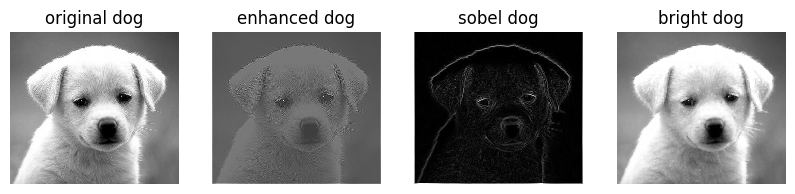

In [35]:
## testing basic helpers

enhanced_dog = enhance_image(dog_img)
sobel_dog = detect_edge(dog_img)
brighten_dog = brighten_image(dog_img)

plt.subplot(1,4,1)
plt.imshow(dog_img)
plt.title('original dog')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(enhanced_dog)
plt.title('enhanced dog')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(sobel_dog)
plt.title('sobel dog')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(brighten_dog)
plt.title('bright dog')
plt.axis('off')

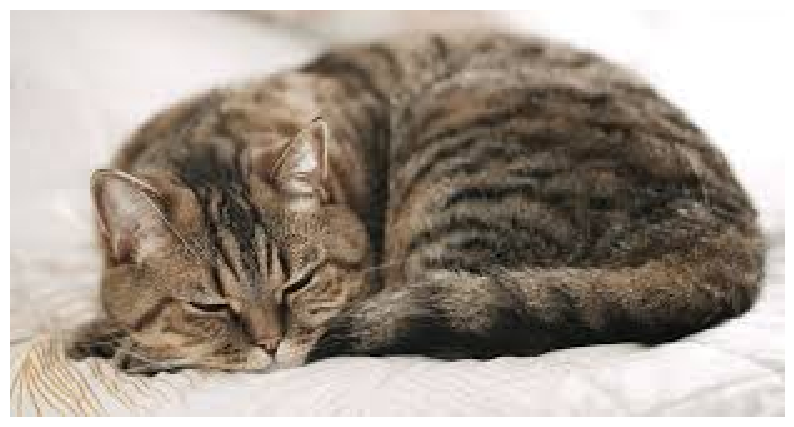

In [18]:
# Open image as grayscale
colored_cat = io.imread('sleeping-cat.jpeg', as_gray=False)

# Show image
plt.imshow(colored_cat)
plt.axis('off')
plt.show()

uint8 0 255
float64 12.73046875 255.0
uint8 0 255
float64 12.73046875 255.0


(np.float64(-0.5), np.float64(309.5), np.float64(162.5), np.float64(-0.5))

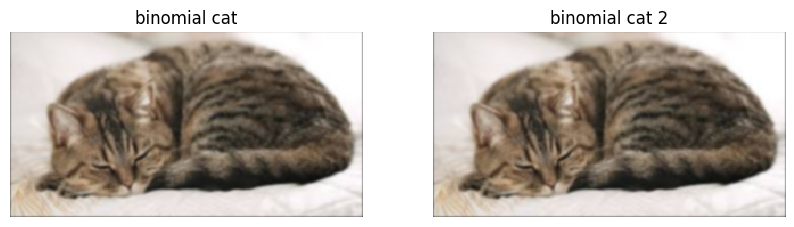

In [36]:
binomial_cat = conv_fast(colored_cat, binomial_filter(5), colored = True)
plt.subplot(1,2,1)
plt.imshow(binomial_cat)
plt.title('binomial cat')
plt.axis('off')

binomial_cat_2 = conv_fast(colored_cat, binomial_filter(5), colored = True)
plt.subplot(1,2,2)
plt.imshow(binomial_cat_2)
plt.title('binomial cat 2')
plt.axis('off')

(np.float64(-0.5), np.float64(309.5), np.float64(162.5), np.float64(-0.5))

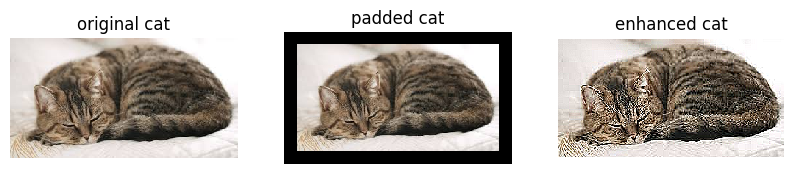

In [37]:
enhanced_colored_cat = enhance_image(colored_cat, colored = True)
padded_cat = zero_pad(colored_cat, 20, 20, colored = True)

plt.subplot(1,3,1)
plt.imshow(colored_cat)
plt.title('original cat')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(padded_cat)
plt.title('padded cat')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(enhanced_colored_cat)
plt.title('enhanced cat')
plt.axis('off')

## note that the enhanced cat looks horrible

In [ ]:
## Brighten, darken, blur images along each color

## a naive multiplication-based scale factor might just blur everything out.
## Idea 1: multiply (max - value)* scale)factor - this works fine for compression (factor < 1) but may break for expansion (factor > 1).
## It also does not work at all for negative factors.
## Idea 2: keep mean the same but re-scale. This doesn't
## a more sophisticated method? (Assume max = 1, min = 0) with value c, c & 1-c...
## c \rightarrow c', 1-c \rightarrow 1-c'; at scale factor = 1, the balance is 1/2, 1/2;
## with factor = a, how about we weight... a/1+a , 1/1+a?
## what are we weighing here?

def invert_color_tone(image):
  if np.issubdtype(image.dtype, np.integer):
    out = 255 - image
  else:
    out = 1 - image
  return out.astype(image.dtype)

def red_filter(image):
  out = np.zeros(image.shape)
  out[:, :, 0] = image[:, :, 0]
  return out.astype(image.dtype)

def green_filter(image):
  out = np.zeros(image.shape)
  out[:, :, 1] = image[:, :, 1]
  return out.astype(image.dtype)

def blue_filter(image):
  out = np.zeros(image.shape)
  out[:, :, 2] = image[:, :, 2]
  return out.astype(image.dtype)

def linear_rescale(image, scale_factor, shift_factor):
  red = image[:, :, 0]
  green = image[:, :, 1]
  blue = image[:, :, 2]

  rscale, gscale, bscale = scale_factor
  rshift, gshift, bshift = shift_factor
  out = np.zeros(image.shape)
  out[:, :, 0] = rscale * red + rshift
  out[:, :, 1] = gscale * green + gshift
  out[:, :, 2] = bscale * blue + bshift

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

def renormalize(image, scale_factor):
  red = image[:, :, 0]
  green = image[:, :, 1]
  blue = image[:, :, 2]
  rscale, gscale, bscale = scale_factor
  rmean = np.mean(red)
  gmean = np.mean(green)
  bmean = np.mean(blue)
  out = np.zeros(image.shape)
  out[:, :, 0] = rscale * (red - rmean)
  out[:, :, 1] = gscale * (green - gmean)
  out[:, :, 2] = bscale * (blue - bmean)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

def sigmoid_rescale(image, scale_factor, shift_factor):
  ## computing with lagrange interpolation:
  red = image[:, :, 0]
  green = image[:, :, 1]
  blue = image[:, :, 2]

  pass


def vignette(image, center = None, scale_factor = None):
  ##  Vignette (v) = a (Distance from Center)^(b). Set a=5.
  ##  pixel value *= (1 - v)
  ##  a is the scale factor. If it is not passed in, default to ensuring that the furthest point is 0.
  ##  This translates to b = -log_{d_max} (5) = - (np.log(5)/np.log(d_max))
  Hi, Wi = image.shape
  if center == None:
    center = (Hi//2, Wi//2)
  x, y = center

  if scale_factor = None:
    dmax = np.sqrt(max(i**2, (Hi-i)**2) + max(j**2, (Wi-j)**2))
    scale_factor = -(np.log(5)/np.log(dmax))

  out = np.zeros(image.shape)
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      distance = np.sqrt((i-x)**2 + (j-y)**2)
      vignette = 1 - np.power(distance, scale_factor)
      out[i][j] = image[i][j] * (1 - vignette)

  if np.issubdtype(image.dtype, np.integer):
    out = np.clip(out, 0, 255)
  return out.astype(image.dtype)

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_